In [1]:
# Load libraries and the raw sensor data
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("../data/member1_raw_sensor_stream.csv")
ref = pd.read_csv("../data/member1_sensor_health.csv")

print("Raw rows:", raw.shape)
print("Reference rows:", ref.shape)
raw.head()

Raw rows: (2959, 17)
Reference rows: (3000, 20)


,message_id,record_id,timestamp_utc,received_at_utc,site_id,device_id,panel_id,voltage_v,current_ma,power_mw,panel_temp1_c,panel_temp2_c,ambient_temp_c,humidity_pct,pressure_hpa,irradiance_lux,dust_vo_v
0,MSG-000001,REC-03001,2026-09-10T01:49:00Z,2026-09-10T01:49:00Z,SITE-B,ESP32-B01,PV-B01,2.710,13.173,35.698,27.62,27.21,23.443,90.658,1009.951,14357.597,1.228
1,MSG-000002,REC-03002,2026-09-10T01:49:05Z,2026-09-10T01:49:05Z,SITE-B,ESP32-B01,PV-B01,2.746,13.277,36.458,27.54,27.10,23.461,90.894,1009.886,14001.182,1.207
2,MSG-000003,REC-03003,2026-09-10T01:49:10Z,2026-09-10T01:49:10Z,SITE-B,ESP32-B01,PV-B01,2.726,12.536,34.178,27.60,27.11,23.589,90.069,1009.881,14085.812,1.060
3,MSG-000004,REC-03004,2026-09-10T01:49:15Z,2026-09-10T01:49:15Z,SITE-B,ESP32-B01,PV-B01,2.710,12.507,33.899,27.65,27.23,23.518,91.519,1009.785,14271.489,1.002
4,MSG-000005,REC-03004,2026-09-10T01:49:15Z,2026-09-10T01:49:15Z,SITE-B,ESP32-B01,PV-B01,2.710,12.507,33.899,27.65,27.23,23.518,91.519,1009.785,14271.489,1.002


In [2]:
# Check the range of each sensor.
# Strange values here show sensor problems.
raw.describe().T[["min", "mean", "max"]]

,min,mean,max
voltage_v,-0.021,2.203310,8.202
current_ma,-100.210,28.612128,166.436
power_mw,0.001,68.511639,521.055
panel_temp1_c,-999.000,23.140294,51.980
panel_temp2_c,-999.000,27.019338,53.070
ambient_temp_c,22.138,27.565106,32.755
humidity_pct,67.847,85.651764,101.164
pressure_hpa,1008.081,1009.569057,1011.372
irradiance_lux,663.632,38008.056504,100000.000
dust_vo_v,0.006,0.276252,1.463


In [3]:
# Count each type of bad reading
print("Temp1 = -127 (sensor disconnected):", (raw["panel_temp1_c"] == -127).sum())
print("Temp1 = -999 (missing value):", (raw["panel_temp1_c"] == -999).sum())
print("Negative current (wire reversed):", (raw["current_ma"] < 0).sum())
print("Lux at 100000 (sensor saturated):", (raw["irradiance_lux"] >= 100000).sum())
print("Humidity over 100%:", (raw["humidity_pct"] > 100).sum())
print("Duplicate records:", raw["record_id"].duplicated().sum())

Temp1 = -127 (sensor disconnected): 106
Temp1 = -999 (missing value): 21
Negative current (wire reversed): 643
Lux at 100000 (sensor saturated): 2
Humidity over 100%: 75
Duplicate records: 18


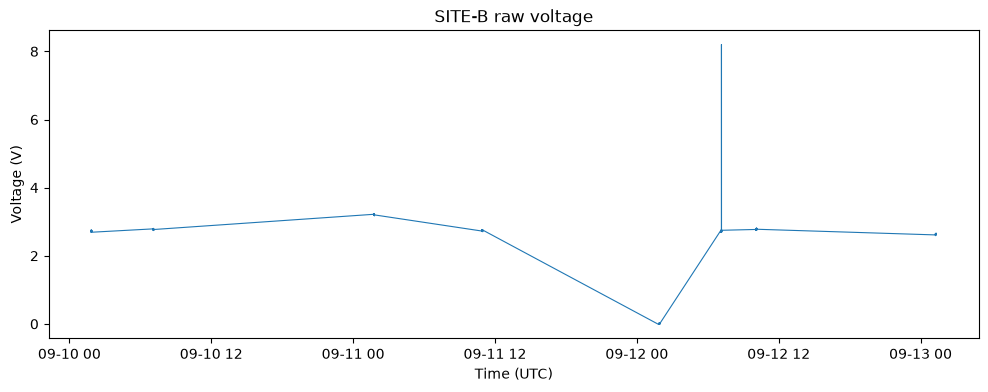

In [4]:
# Plot voltage for one site to see the noise
site = raw[raw["site_id"] == "SITE-B"].copy()
site["timestamp_utc"] = pd.to_datetime(site["timestamp_utc"])

plt.figure(figsize=(12, 4))
plt.plot(site["timestamp_utc"], site["voltage_v"], linewidth=0.8)
plt.title("SITE-B raw voltage")
plt.xlabel("Time (UTC)")
plt.ylabel("Voltage (V)")
plt.show()

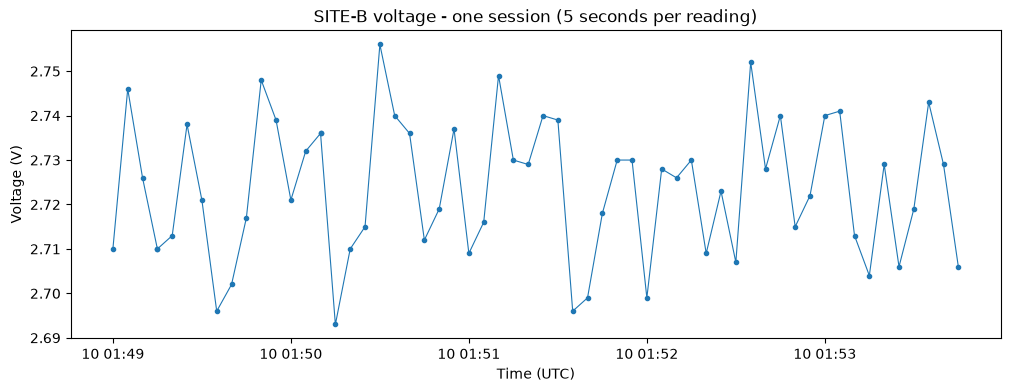

In [5]:
# Zoom into one 5-minute session to see the noise.
# The first 60 SITE-B rows are one session.
one_run = site.head(60)

plt.figure(figsize=(12, 4))
plt.plot(one_run["timestamp_utc"], one_run["voltage_v"],
         marker="o", markersize=3, linewidth=0.8)
plt.title("SITE-B voltage - one session (5 seconds per reading)")
plt.xlabel("Time (UTC)")
plt.ylabel("Voltage (V)")
plt.show()